# Problem 2

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description
- <b>Consider a grid of N buses to which generators and loads are connected, and discover a grid loss function based on M per-bus power injection readings and the corresponding M total grid loss measurements.<b>

    _______________________________________________________________________________________________________________________

Considered "Kite" 5 Bus Network
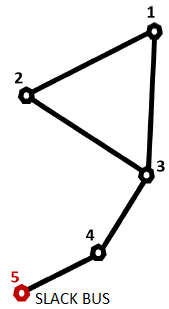

- <b>Implementation.<b>
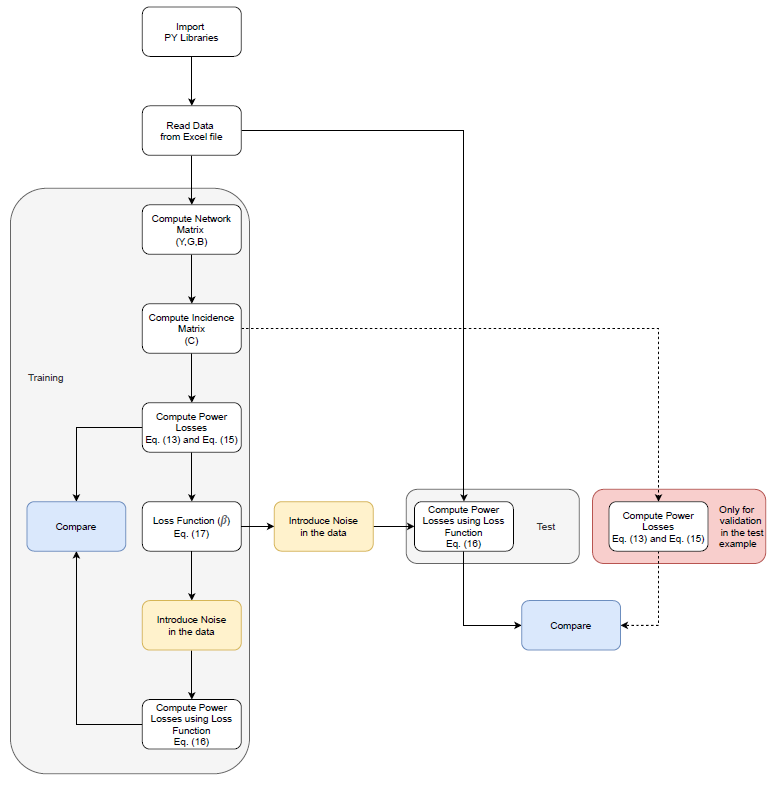

<b>Import Python Libraries

In [37]:
import pandas as pd
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt


<b>Parameters

In [38]:
noiseFactor=0.0025     #noise
networkFactor=100      #to change the characteristics of the network (Y)
PtestFactor=3          #to obtain losses similar to the training data;

<b>Import data (From Excel file)

In [39]:
Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (train)
Power_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus) - (Train)\n", Power_Info, "\n")

#Power Information (test)
Power_Test = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus) - (Test)\n", Power_Test)

time=Power_Info.shape[0]
P=Power_Info
Ptest=Power_Test *PtestFactor

Slack Bus:  5 

Lines information (Admitances)
 [[1 2 '0,01-0,1i']
 [1 3 '0,02-0,2i']
 [2 3 '0,03-0,2i']
 [3 4 '0,03-0,2i']
 [4 5 '0,02-0,2i']] 

Power consumption information (time, Bus) - (Train)
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]
 [0.684 0.528 0.256 0.44 ]] 

Power consumption information (time, Bus) - (Test)
 [[0.18  0.06  0.188 0.132]
 [0.1   0.06  0.992 0.132]
 [0.388 0.1   1.576 0.132]
 [0.28  0.196 0.08  1.94 ]
 [0.5   0.184 0.064 0.572]
 [1.16  0.108 0.064 0.188]
 [1.036 0.06  0.068 0.08 ]
 [1.036 0.064 0.112 0.064]
 [1.768 0.064 0.2   0.068]
 [0.804 0.092 0.184 0.064]
 [0.824 0.196 0.088 0.096]
 [0.52  0.188 0.064 0.196]
 [0.184 0.104 0.068 0.192]]


<b>Admittance Matrix(Y); Conductance Matrix(G); Susceptance Matrix(B)

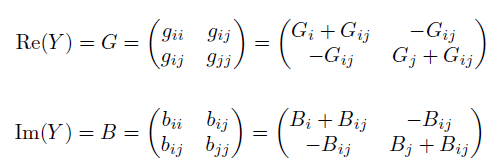

In [40]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 
print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")


The admitance matrix Y is:
 [[ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-30.  10.  20.   0.]
 [ 10. -30.  20.   0.]
 [ 20.  20. -60.  20.]
 [  0.   0.  20. -40.]] 



<b>Incidence Matrix (Bus,Lines)

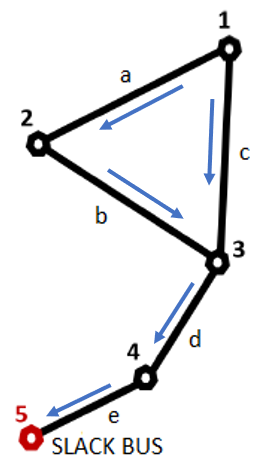

In [41]:
# Create the vectors
C=np.zeros((nBus,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y.shape[0]):
    for j in range (i+1,Y.shape[1]):
        if np.absolute(Y[i,j])!=0:
            C[i,nLine_Aux]=1
            C[j,nLine_Aux]=-1
            nLine_Aux=nLine_Aux+1           

#Remove the slack bus from the matrix
Cl=np.delete(C, np.s_[SlackBus-1], axis=0)

print ("The incidence matrix C (nBus,nLines) is:\n",Cl)

The incidence matrix C (nBus,nLines) is:
 [[ 1.  1.  0.  0.  0.]
 [-1.  0.  1.  0.  0.]
 [ 0. -1. -1.  1.  0.]
 [ 0.  0.  0. -1.  1.]]


<b>Definition of Matrix Gij (Diagonal and vector)

In [42]:
# Create the vectors
Gv=np.zeros((1,nLines))
Gd=np.zeros((nLines,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y.shape[0]):
    for j in range (i+1,Y.shape[1]):
        if np.absolute(Y[i,j])!=0:
            Gv[0,nLine_Aux]=-np.real(Y[i,j])          #Information about the lines condutance [Vector]
            Gd[nLine_Aux,nLine_Aux]=-np.real(Y[i,j])  #Information about the lines condutance [Diagonal in matrix]
            nLine_Aux=nLine_Aux+1           


print ("Gij_Diag:\n",Gd)

Gij_Diag:
 [[1. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 2.]]


<b>Definition of the Power Losses in two different ways, following equations (13) and (15) of lectures.

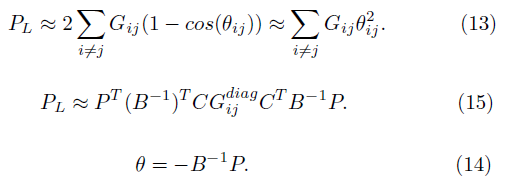

In [43]:
#Matrix creation
teta=np.zeros((nBus-1,time))
grau=np.zeros((nLines,time))
PL=np.zeros((time))
PL2=np.zeros((time))
PT=np.zeros((time))
rLoss=np.zeros((time))

#Losses
alfa=np.dot(np.dot(np.dot(np.dot(np.linalg.inv(B),Cl),Gd),np.transpose(Cl)),np.linalg.inv(B))  #Used in Equation (15)

for m in range (time):
    PL[m]=np.dot(P[m,:],np.dot(alfa,np.transpose(P[m,:])))  #Power Losses using equation (15)
    
    teta[:,m]=np.dot(np.linalg.inv(B),np.transpose(P[m,:])) #Voltage angle (Teta). Equation (14) 

    grau[:,m]=np.dot(np.transpose(Cl),teta[:,m])            #Voltage angle difference (Teta ij)

    PL2[m]=np.dot(2*Gv,1-np.cos(grau[:,m]))                 #Power Losses using equation (13)

    PT[m]=np.sum([P[m,:]])                                  #Total Power   

    rLoss[m]=np.divide(PL2[m],PT[m])                        #Power Losses (%)


print ("Total Power consumption:\n",PT ,"\n")    
print ("Power Losses obtained using the Theta:\n",PL2 ,"\n")  
print ("Power Losses obtained without using the Theta:\n",PL ,"\n")  

Total Power consumption:
 [0.6   0.74  2.576 5.168 5.456 5.476 5.012 3.252 3.664 5.388 2.212 1.504
 1.908] 

Power Losses obtained using the Theta:
 [0.0040525  0.00665397 0.08342236 0.38413184 0.30832255 0.39635134
 0.17306509 0.08269704 0.15806927 0.38605897 0.05446394 0.02942382
 0.0388501 ] 

Power Losses obtained without using the Theta:
 [0.00405272 0.00665461 0.0835298  0.38592245 0.3096688  0.39823976
 0.1737622  0.08283    0.15840609 0.38795136 0.05450801 0.02943516
 0.0388715 ] 



C:\Users\ASUS\AppData\Local\Temp\ipykernel_5424\1408284392.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  PL2[m]=np.dot(2*Gv,1-np.cos(grau[:,m]))                 #Power Losses using equation (13)


<b>Discovering the loss function

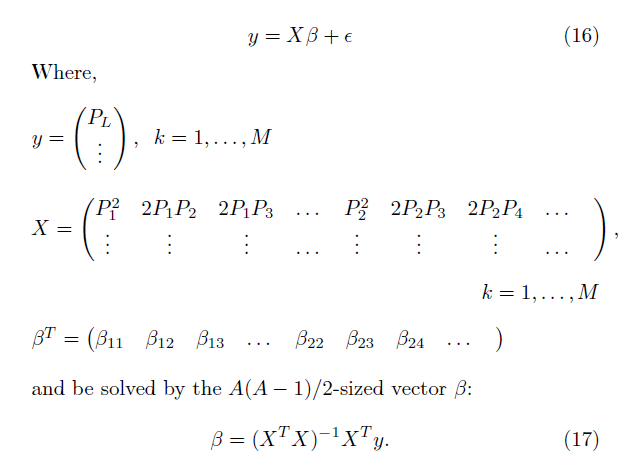

In [44]:
# Discovering the loss function (beta) used in equation 13

# For that we first need to get X matrix from P

T, n = P.shape
q = n + n * (n - 1) // 2
X = np.zeros((T, q))
for m in range (time):
    k = 0
    for i in range(n):
        X[m, k] = P[m, i]**2
        k += 1
    for i in range(n):
        for j in range(i + 1, n):
            X[m, k] = 2 * P[m, i] * P[m, j]
            k += 1


# Add noise to the power losses
PL2_noisy = PL2 *(1 + noiseFactor * np.random.normal(size=PL2.shape))

# Discover beta for both the original and noisy power losses
beta = np.linalg.lstsq(X, PL2, rcond=None)[0]
beta_noisy = np.linalg.lstsq(X, PL2_noisy, rcond=None)[0]

# predictions
PL_predicted = X.dot(beta)
PL_predicted_noisy = X.dot(beta_noisy)

# performance
mse_13 = np.mean((PL2 - PL_predicted)**2)
mse_13_noisy = np.mean((PL2_noisy - PL_predicted_noisy)**2)

# print the discovered beta values
print("Discovered beta for equation 13 (no noise):\n", beta)
print("Discovered beta for equation 13 (with noise):\n", beta_noisy)

# Print the predicted losses
print("Predicted Power Losses using equation 13 (no noise):\n", PL_predicted)
print("Predicted Power Losses using equation 13 (with noise):\n", PL_predicted_noisy)

print("MSE for equation 13 (no noise):\n", mse_13)
print("MSE for equation 13 (with noise):\n", mse_13_noisy)


Discovered beta for equation 13 (no noise):
 [0.01635835 0.01684308 0.01173772 0.00519595 0.01489069 0.01214016
 0.0041297  0.01340756 0.00481611 0.00610852]
Discovered beta for equation 13 (with noise):
 [0.01618549 0.01618662 0.01127797 0.00502846 0.0152666  0.01177698
 0.00467035 0.01427795 0.00448136 0.00610629]
Predicted Power Losses using equation 13 (no noise):
 [0.00400998 0.00666911 0.08342106 0.38413193 0.30832279 0.39635107
 0.17306743 0.08268722 0.1580733  0.38606087 0.05447411 0.02937098
 0.03885548]
Predicted Power Losses using equation 13 (with noise):
 [0.00402555 0.00667593 0.08373005 0.383076   0.3079579  0.39437122
 0.17306869 0.08303677 0.1587148  0.38497359 0.0544787  0.02932779
 0.03907806]
MSE for equation 13 (no noise):
 3.9115700944984273e-10
MSE for equation 13 (with noise):
 3.673099388877083e-09


<b>Plot Results (Training)

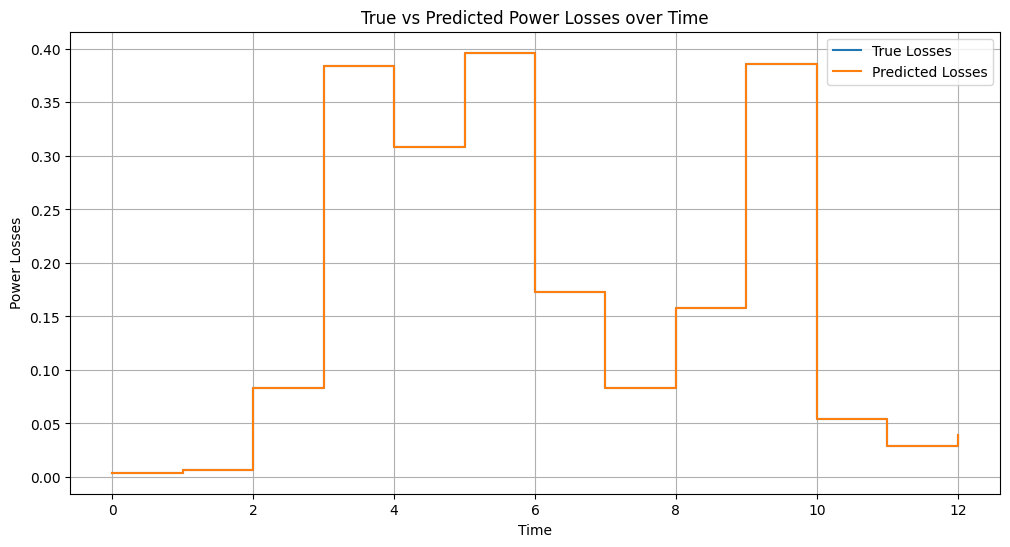

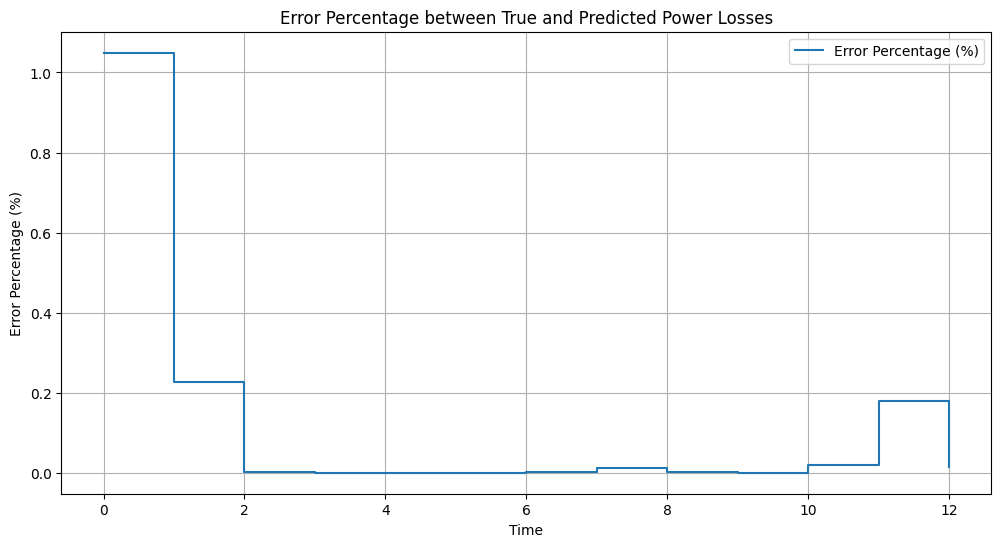

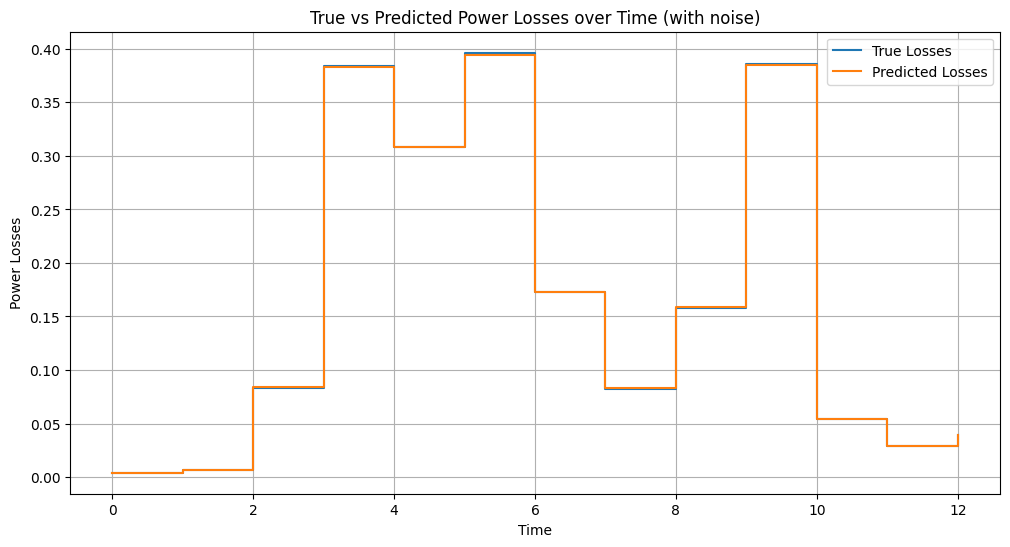

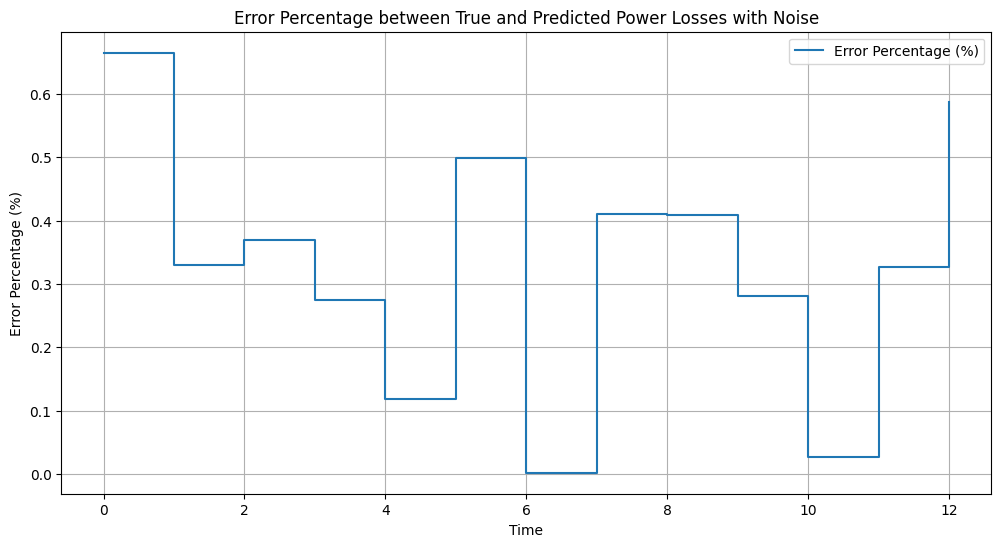

In [45]:
# Plotting the results

# Plotting losses expected vs the predicted losses with relation to time stamps no noise
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2, label='True Losses', where='post')
plt.step(range(time), PL_predicted, label='Predicted Losses', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time')
plt.legend()
plt.grid(True)
plt.show()

error_percent = abs((PL_predicted - PL2) / PL2 * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent, label='Error Percentage (%)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage between True and Predicted Power Losses')
plt.legend()
plt.grid(True)
plt.show()


# Plotting losses expected vs the predicted losses with relation to time stamps with noise
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2, label='True Losses', where='post')
plt.step(range(time), PL_predicted_noisy, label='Predicted Losses', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time (with noise)')
plt.legend()
plt.grid(True)
plt.show()

error_percent_noisy = abs((PL_predicted_noisy - PL2) / PL2 * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent_noisy, label='Error Percentage (%)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage between True and Predicted Power Losses with Noise')
plt.legend()
plt.grid(True)
plt.show()

**Test DataSet**
    
Use Loss Function (Beta Coeficients), to compute the losses considering a new Power Consumption dataset (Ptest). 

Predicted Power Losses for the test set (no noise):
 [0.02805755 0.16050426 0.49676285 0.30783638 0.12657394 0.27272415
 0.19956481 0.21108283 0.58675929 0.16208857 0.17877139 0.0959254
 0.02419902]
Real Power Losses for the test set (no noise):
 [0.02810458 0.16402155 0.50727653 0.3041819  0.12908225 0.2745438
 0.20044721 0.21186304 0.58665269 0.16270114 0.17836281 0.09644313
 0.02434283]
MSE for the test set (no noise):
 1.1392203563903036e-05


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5424\3582228633.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  PL2_test[m]=np.dot(2*Gv,1-np.cos(grau_test[:,m]))                 #Power Losses using equation (13) for the test data


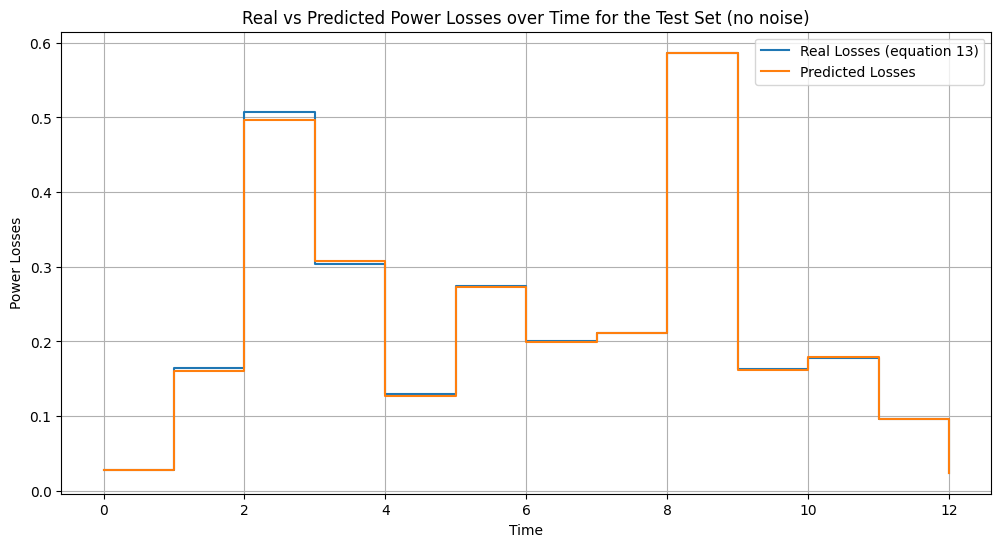

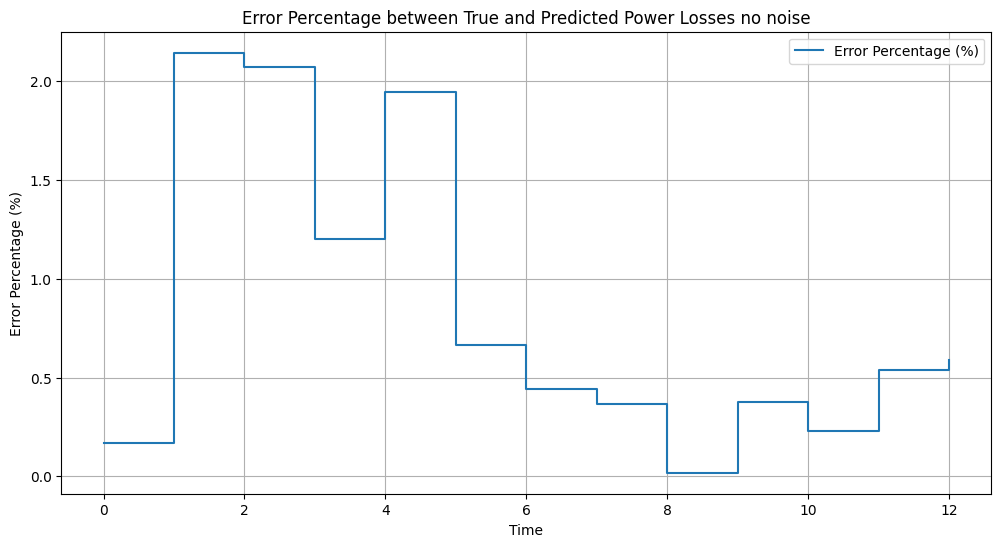

In [46]:
# Use my betas and predicted loss function to predict losses and compare with the true losses

# First compute real losses
teta_test=np.zeros((nBus-1,time))
grau_test=np.zeros((nLines,time))
PL2_test=np.zeros((time))
PT_test=np.zeros((time))
rLoss_test=np.zeros((time))

for m in range (time):
    teta_test[:,m]=np.dot(np.linalg.inv(B),np.transpose(Ptest[m,:])) #Voltage angle (Teta) for the test data. Equation (14)

    grau_test[:,m]=np.dot(np.transpose(Cl),teta_test[:,m])            #Voltage angle difference (Teta ij) for the test data

    PL2_test[m]=np.dot(2*Gv,1-np.cos(grau_test[:,m]))                 #Power Losses using equation (13) for the test data

    PT_test[m]=np.sum([Ptest[m,:]])                                  #Total Power for the test data

    rLoss_test[m]=np.divide(PL2_test[m],PT_test[m])                        #Power Losses (%) for the test data

# Compute X using the test data power injections
T, n = P.shape
q = n + n * (n - 1) // 2
X_test = np.zeros((T, q))
for m in range (time):
    k = 0
    for i in range(n):
        X_test[m, k] = Ptest[m, i]**2
        k += 1
    for i in range(n):
        for j in range(i + 1, n):
            X_test[m, k] = 2 * Ptest[m, i] * Ptest[m, j]
            k += 1

# We can add noise to the power losses

# Compute the predicted losses for the test data using the beta model trained before
PL_predicted_test = X_test.dot(beta)

print("Predicted Power Losses for the test set (no noise):\n", PL_predicted_test)
print("Real Power Losses for the test set (no noise):\n", PL2_test)

# Compare the predicted losses with the real losses for the test set
mse_test = np.mean((PL2_test - PL_predicted_test)**2)
print("MSE for the test set (no noise):\n", mse_test)

# Plotting the predicted losses vs the real losses for the test set
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2_test, label='Real Losses (equation 13)', where='post')
plt.step(range(time), PL_predicted_test, label='Predicted Losses', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('Real vs Predicted Power Losses over Time for the Test Set (no noise)')
plt.legend()
plt.grid(True)
plt.show()

error_percent_test = abs((PL_predicted_test - PL2_test) / PL2_test * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent_test, label='Error Percentage (%)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage between True and Predicted Power Losses no noise')
plt.legend()
plt.grid(True)
plt.show()



# Estimations with noise (code not adapted)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5424\3768606364.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  PL_test_eq13[m] = np.dot(2*Gv, 1 - np.cos(grau_test[:,m]))


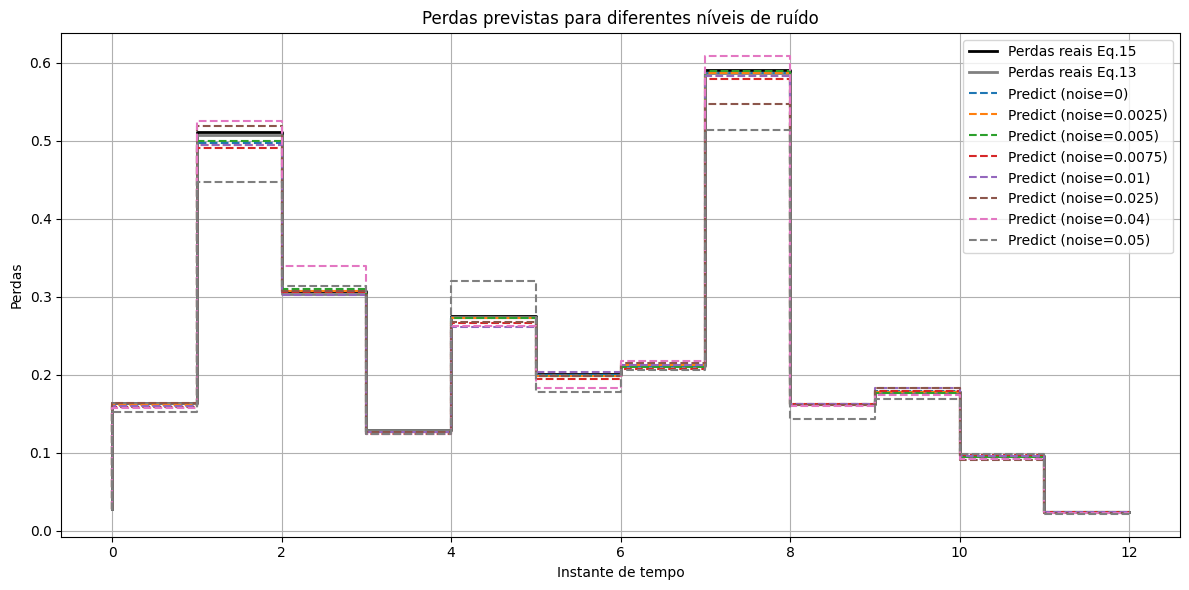

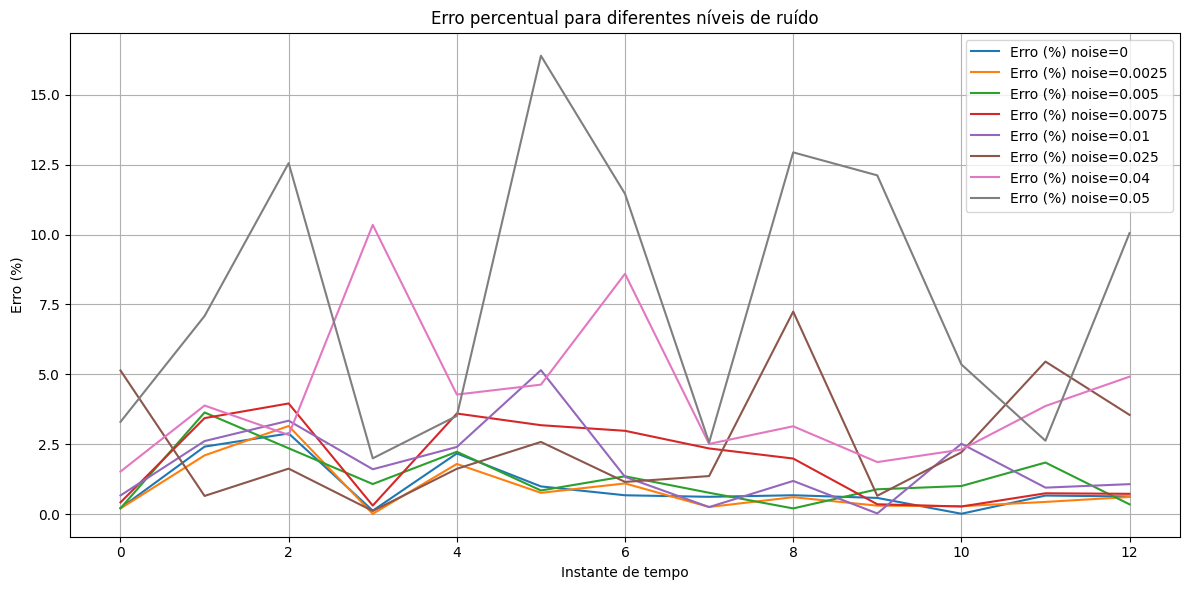

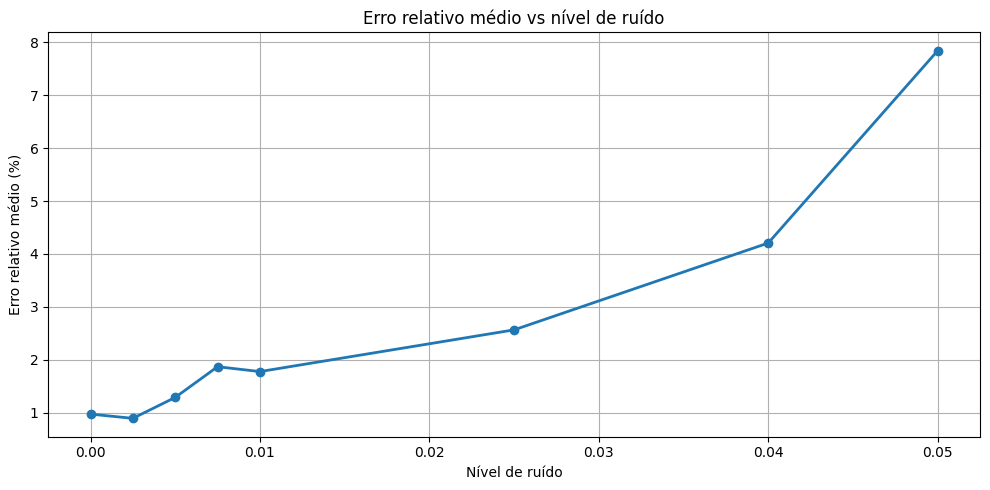

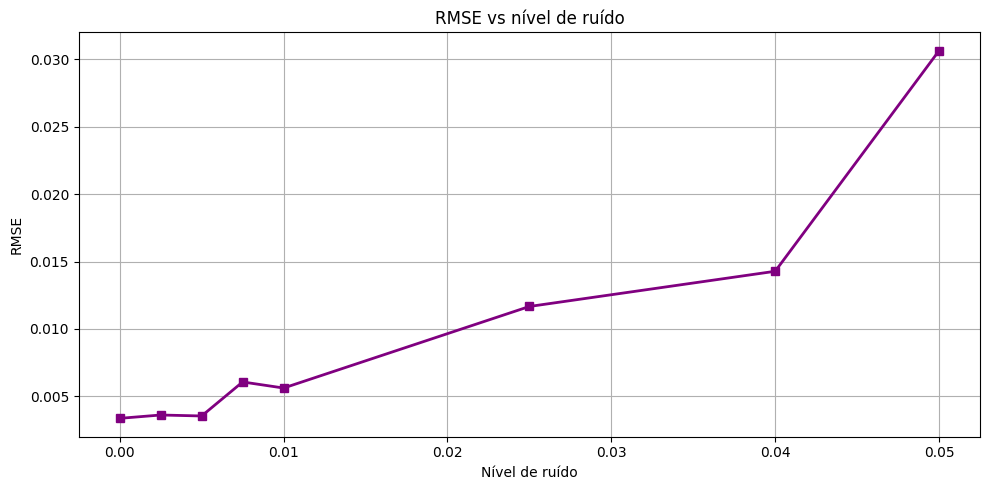

In [47]:
# Níveis de ruído a estudar
noise_levels = [0, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.04, 0.05]

# Compute X using the test data power injections
T, n = P.shape
q = n + n * (n - 1) // 2
X_test = np.zeros((T, q))
for m in range (time):
    k = 0
    for i in range(n):
        X_test[m, k] = Ptest[m, i]**2
        k += 1
    for i in range(n):
        for j in range(i + 1, n):
            X_test[m, k] = 2 * Ptest[m, i] * Ptest[m, j]
            k += 1

## Perdas previstas sem ruído
PL_test_pred_clean = X_test @ beta

## Cálculo das perdas reais Eq.13 e Eq.15
PL_test_eq15 = np.zeros(time)
PL_test_eq13 = np.zeros(time)

teta_test = np.zeros((B.shape[0], time))
grau_test = np.zeros((Cl.shape[1], time))

for m in range(time):

    PL_test_eq15[m] = np.dot(Ptest[m,:],
                             np.dot(alfa, Ptest[m,:].T))

    teta_test[:,m] = np.dot(np.linalg.inv(B), Ptest[m,:].T)

    grau_test[:,m] = np.dot(Cl.T, teta_test[:,m])

    PL_test_eq13[m] = np.dot(2*Gv, 1 - np.cos(grau_test[:,m]))


# -----------------------------
# 1) GRÁFICO COM TODAS AS CURVAS DE RUÍDO
# -----------------------------

plt.figure(figsize=(12, 6))

plt.step(range(time), PL_test_eq15, label='Perdas reais Eq.15', linewidth=2, color='black')
plt.step(range(time), PL_test_eq13, label='Perdas reais Eq.13', linewidth=2, color='gray')

predictions_by_noise = {}
errors_by_noise = {}

for noise in noise_levels:
    noise_test = noise * np.random.randn(*Ptest.shape)
    Ptest_noisy = Ptest * (1 + noise_test)

    # Construir X_test ruidoso
    X_test_noisy = np.zeros((T, q))
    for m in range(time):
        k = 0
        for i in range(n):
            X_test_noisy[m, k] = Ptest_noisy[m, i]**2
            k += 1
        for i in range(n):
            for j in range(i + 1, n):
                X_test_noisy[m, k] = 2 * Ptest_noisy[m, i] * Ptest_noisy[m, j]
                k += 1

    PL_pred_noises = X_test_noisy @ beta
    predictions_by_noise[noise] = PL_pred_noises

    plt.step(range(time),PL_pred_noises, '--', linewidth=1.5, label=f'Predict (noise={noise})')

plt.xlabel("Instante de tempo")
plt.ylabel("Perdas")
plt.title("Perdas previstas para diferentes níveis de ruído")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 2) GRÁFICO DO ERRO PERCENTUAL PARA CADA RUÍDO
# -----------------------------

plt.figure(figsize=(12, 6))

for noise in noise_levels:
    PL_pred_noises = predictions_by_noise[noise]
    error_percent_noises = np.abs((PL_pred_noises - PL_test_eq15) / PL_test_eq15) * 100
    errors_by_noise[noise] = error_percent_noises
    plt.plot(error_percent_noises, label=f"Erro (%) noise={noise}")

plt.xlabel("Instante de tempo")
plt.ylabel("Erro (%)")
plt.title("Erro percentual para diferentes níveis de ruído")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 3) ERRO RELATIVO MÉDIO POR NÍVEL DE RUÍDO
# -----------------------------

mean_errors = [np.mean(errors_by_noise[n]) for n in noise_levels]

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, mean_errors, 'o-', linewidth=2)
plt.xlabel("Nível de ruído")
plt.ylabel("Erro relativo médio (%)")
plt.title("Erro relativo médio vs nível de ruído")
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------
# 4) RMSE POR NÍVEL DE RUÍDO
# -----------------------------

rmse_values = [
    np.sqrt(np.mean((predictions_by_noise[n] - PL_test_eq13)**2))
    for n in noise_levels
]

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, rmse_values, 's-', linewidth=2, color='purple')
plt.xlabel("Nível de ruído")
plt.ylabel("RMSE")
plt.title("RMSE vs nível de ruído")
plt.grid(True)
plt.tight_layout()
plt.show()

# Vector initialization

TO BE DONE. You should compare the three methods considering the test data

In [48]:
# need to implement the code for test data with noise, comparing the three methods

# Challenges
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- Assume the grid is a LV grid and rewrite (16) assuming that angle differences are negligible (only voltage magnitudes differences are expressive). Assume that in LV grids, Bij << Gij.
- Replace the matrix X, in Equation 16, for:\n
    - i) a matrix X' considering the network structure (only use 2.Pi.Pj when a line connection exists). 
    - ii) reducing the dimensionality of X by considering squared injections (Page 33 in the lectures notes) 
    - iii) reducing the dimensionality of X by summing electrically close bus injections before using them as explanatory variables of losses (Page 33 in the lectures notes)
    - Compare with the proposed method in a larger network


The admitance matrix Y is:
 [[ 3.-0.3j -1.+0.1j -2.+0.2j  0.+0.j   0.+0.j ]
 [-1.+0.1j  4.-0.3j -3.+0.2j  0.+0.j   0.+0.j ]
 [-2.+0.2j -3.+0.2j  8.-0.6j -3.+0.2j  0.+0.j ]
 [ 0.+0.j   0.+0.j  -3.+0.2j  5.-0.4j -2.+0.2j]
 [ 0.+0.j   0.+0.j   0.+0.j  -2.+0.2j  2.-0.2j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-0.3  0.1  0.2  0. ]
 [ 0.1 -0.3  0.2  0. ]
 [ 0.2  0.2 -0.6  0.2]
 [ 0.   0.   0.2 -0.4]] 

The incidence matrix C (nBus,nLines) is:
 [[ 1.  1.  0.  0.  0.]
 [-1.  0.  1.  0.  0.]
 [ 0. -1. -1.  1.  0.]
 [ 0.  0.  0. -1.  1.]]
Gij_Diag:
 [[1. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 2.]]

Power Losses using LV approximation:
 [ 0.22872   0.18904  12.86832  29.185072 17.906928 28.140208 33.5092
  8.153088  5.142288 25.094672  1.275744  1.163168  1.101424] 


Coeficientes da loss function (B):
 [ 3.00000000e+00  4.00000000e+00  8.00000000e+00  5

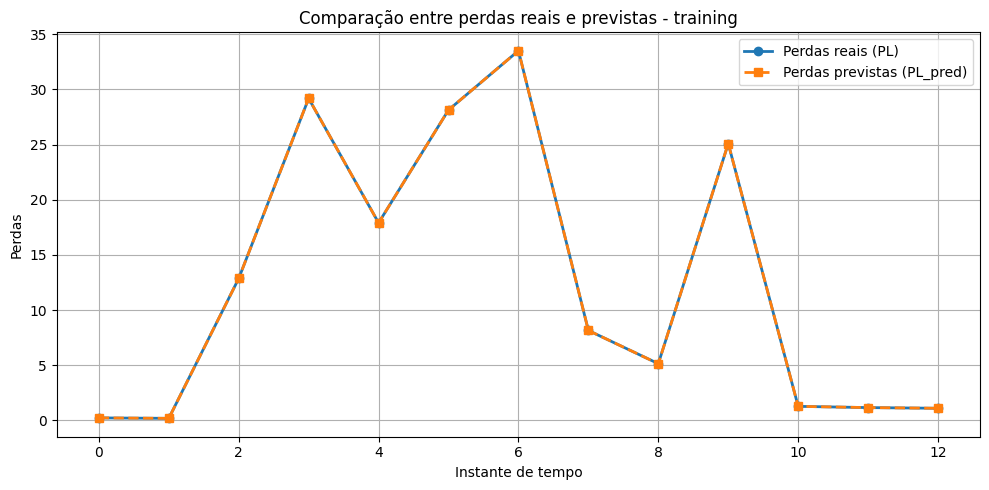

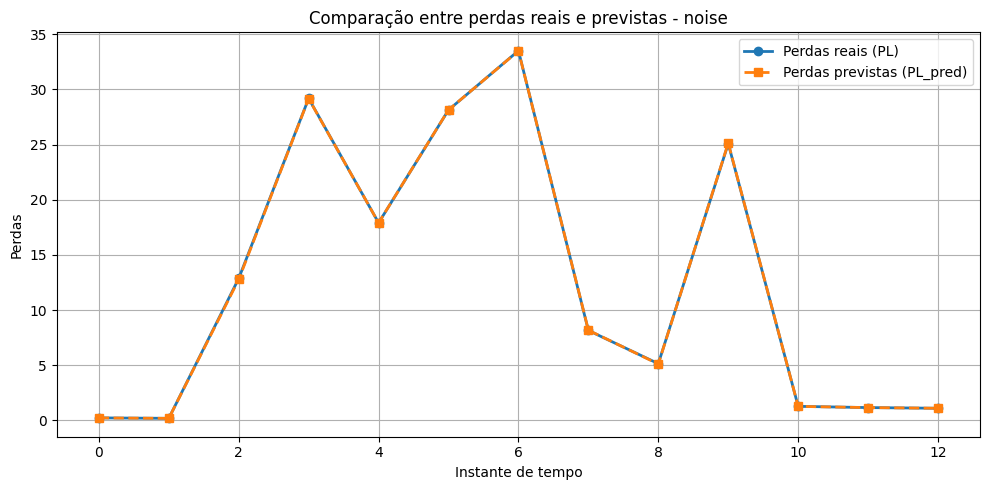


Ficheiro Excel 'Resultados_PowerLosses_training.xlsx' criado com sucesso!


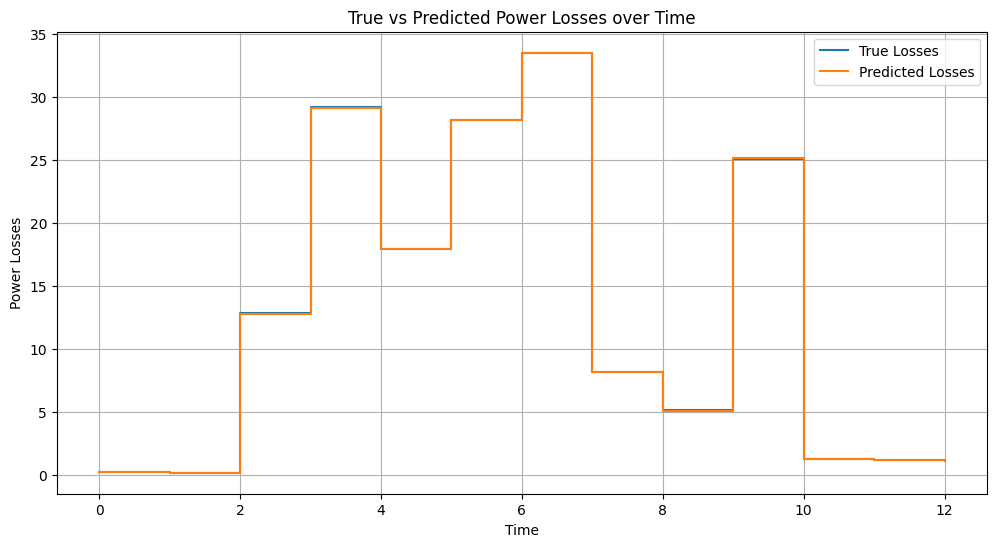

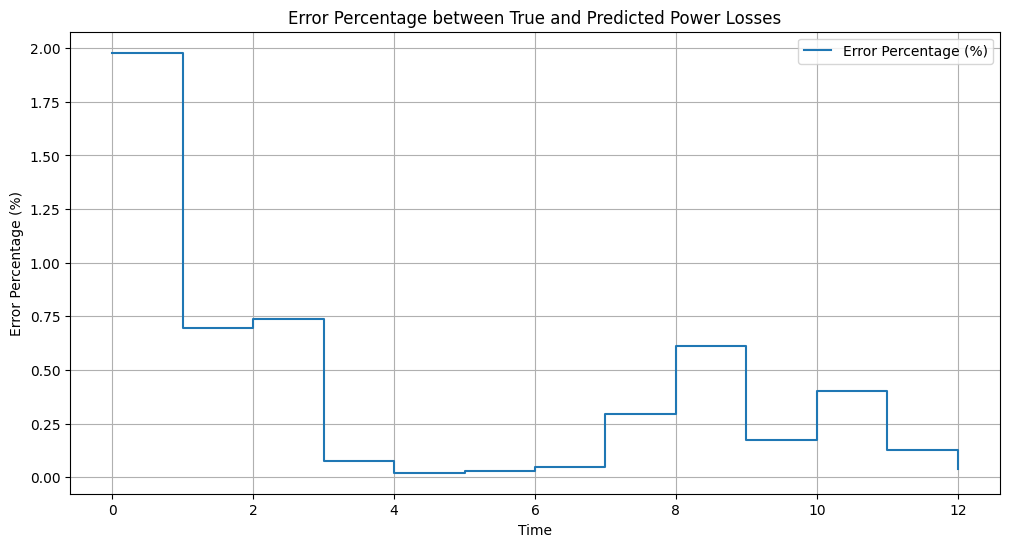

Mean |G|: 2.375
Mean |B|: 0.1875
Ratio G/B: 12.666666666666666


In [49]:
Y_LV=np.zeros((nBus,nBus), dtype=complex)

# LV Grid: G >> B - SO ALTEREI AQUI
for i in range(Net_Info.shape[0]):
    y_aux = Net_Info[i,2].replace(",",".")
    y_aux = y_aux.replace("i","j")
    
    y_line = complex(y_aux)  
    
    y_lv = complex(y_line.real * networkFactor, y_line.imag)

    Y_LV[Net_Info[i,0]-1, Net_Info[i,0]-1] += y_lv
    Y_LV[Net_Info[i,1]-1, Net_Info[i,1]-1] += y_lv
    Y_LV[Net_Info[i,0]-1, Net_Info[i,1]-1] -= y_lv
    Y_LV[Net_Info[i,1]-1, Net_Info[i,0]-1] -= y_lv

# Remove the slack bus from the admitance matrix            
Yl_lv=np.delete(Y_LV, np.s_[SlackBus-1], axis=0)
Yl_lv=np.delete(Yl_lv, np.s_[SlackBus-1], axis=1)

P_lv = P.copy()

# Conductance Matrix
G_lv=Yl_lv.real
B_lv=Yl_lv.imag

# Susceptance Matrix
B_lv=Yl_lv.imag 
print("The admitance matrix Y is:\n", Y_LV, "\n")
print("The conductance matrix G is\n", G_lv, "\n")
print("The susceptance matrix B is\n",B_lv, "\n")

# Create the vectors
C_lv=np.zeros((nBus,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y_LV.shape[0]):
    for j in range (i+1,Y_LV.shape[1]):
        if np.absolute(Y_LV[i,j])!=0:
            C_lv[i,nLine_Aux]=1
            C_lv[j,nLine_Aux]=-1
            nLine_Aux=nLine_Aux+1           

#Remove the slack bus from the matrix
Cl_lv=np.delete(C_lv, np.s_[SlackBus-1], axis=0)

print ("The incidence matrix C (nBus,nLines) is:\n",Cl_lv)

# Create the vectors
Gv_lv=np.zeros((1,nLines))
Gd_lv=np.zeros((nLines,nLines))
nLine_Aux=0

# Determine the Incidence Matrix
for i in range (Y_LV.shape[0]):
    for j in range (i+1,Y_LV.shape[1]):
        if np.absolute(Y_LV[i,j])!=0:
            Gv_lv[0,nLine_Aux]=-np.real(Y_LV[i,j])          #Information about the lines condutance [Vector]
            Gd_lv[nLine_Aux,nLine_Aux]=-np.real(Y_LV[i,j])  #Information about the lines condutance [Diagonal in matrix]
            nLine_Aux=nLine_Aux+1           


print ("Gij_Diag:\n",Gd_lv)

#Matrix creation
teta_lv=np.zeros((nBus-1,time))
grau_lv=np.zeros((nLines,time))
PL2_lv=np.zeros((time))
PT_lv=np.zeros((time))
rLoss_lv=np.zeros((time))

#Losses
alfa_lv=np.dot(np.dot(np.dot(np.dot(np.linalg.inv(B_lv),Cl_lv),Gd_lv),Cl_lv.T),np.linalg.inv(B_lv))
PL_lv = np.zeros(time)

for m in range(time):
    PL_lv[m] = np.dot(P_lv[m,:], np.dot(G_lv, P_lv[m,:]))


print("\nPower Losses using LV approximation:\n", PL_lv, "\n")


T, n = P.shape
q = n + n * (n - 1) // 2
X_lv = np.zeros((T, q))
for m in range (time):
    k = 0
    for i in range(n):
        X_lv[m, k] = P_lv[m, i]**2
        k += 1
    for i in range(n):
        for j in range(i + 1, n):
            X_lv[m, k] = 2 * P_lv[m, i] * P_lv[m, j]
            k += 1


# Add noise to the power losses
PL_lv_noisy = PL_lv *(1 + noiseFactor * np.random.normal(size=PL2_lv.shape))
P_lv_noisy = P_lv *(1 + noiseFactor * np.random.normal(size=P_lv.shape))

# Discover beta for both the original and noisy power losses

# B = np.linalg.lstsq(X, PL, rcond=None)[0]
beta_lv = np.linalg.lstsq(X_lv, PL_lv, rcond=None)[0]
beta_lv_noisy = np.linalg.lstsq(X_lv, PL_lv_noisy, rcond=None)[0]


print("\nCoeficientes da loss function (B):\n", beta_lv)
print("\nDimensão de B:", beta_lv.shape)


## Compute power losses using losses function coefficients
PL_lv_pred = X_lv @ beta_lv
PL_lv_noisy_pred = X_lv @ beta_lv_noisy

print("\nPerdas previstas pelo modelo (PL_pred):\n", PL_lv_pred.flatten())

## Compare the predicted losses with the actual losses

erro_abs = np.abs(PL_lv_pred.flatten() - PL_lv)
erro_rel = erro_abs / PL_lv

print("\nErro absoluto:")
print(erro_abs)

print("\nErro relativo:")
print(erro_rel)

plt.figure(figsize=(10,5))
plt.plot(PL_lv, 'o-', label='Perdas reais (PL)', linewidth=2)
plt.plot(PL_lv_pred, 's--', label='Perdas previstas (PL_pred)', linewidth=2)
plt.xlabel("Instante de tempo")
plt.ylabel("Perdas")
plt.title("Comparação entre perdas reais e previstas - training")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(PL_lv, 'o-', label='Perdas reais (PL)', linewidth=2)
plt.plot(PL_lv_noisy_pred, 's--', label='Perdas previstas (PL_pred)', linewidth=2)
plt.xlabel("Instante de tempo")
plt.ylabel("Perdas")
plt.title("Comparação entre perdas reais e previstas - noise")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "PL_real": PL_lv,
    "PL_pred": PL_lv_pred.flatten(),
    "Erro_abs": erro_abs,
    "Erro_rel": erro_rel,
    "P1": P[:,0],
    "P2": P[:,1],
    "P3": P[:,2],
    "P4": P[:,3]
})

df.to_excel("Resultados_PowerLosses_training.xlsx", index=False)

print("\nFicheiro Excel 'Resultados_PowerLosses_training.xlsx' criado com sucesso!")

## Graficos como o stor quer
plt.figure(figsize=(12, 6))
plt.step(range(time), PL_lv, label='True Losses', where='post')
plt.step(range(time), PL_lv_noisy_pred, label='Predicted Losses', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time')
plt.legend()
plt.grid(True)
plt.show()

error_percent_lv = abs((PL_lv_noisy_pred - PL_lv) / PL_lv * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent_lv, label='Error Percentage (%)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage between True and Predicted Power Losses')
plt.legend()
plt.grid(True)
plt.show()

print("Mean |G|:", np.mean(np.abs(G_lv)))
print("Mean |B|:", np.mean(np.abs(B_lv)))
print("Ratio G/B:", np.mean(np.abs(G_lv))/np.mean(np.abs(B_lv)))

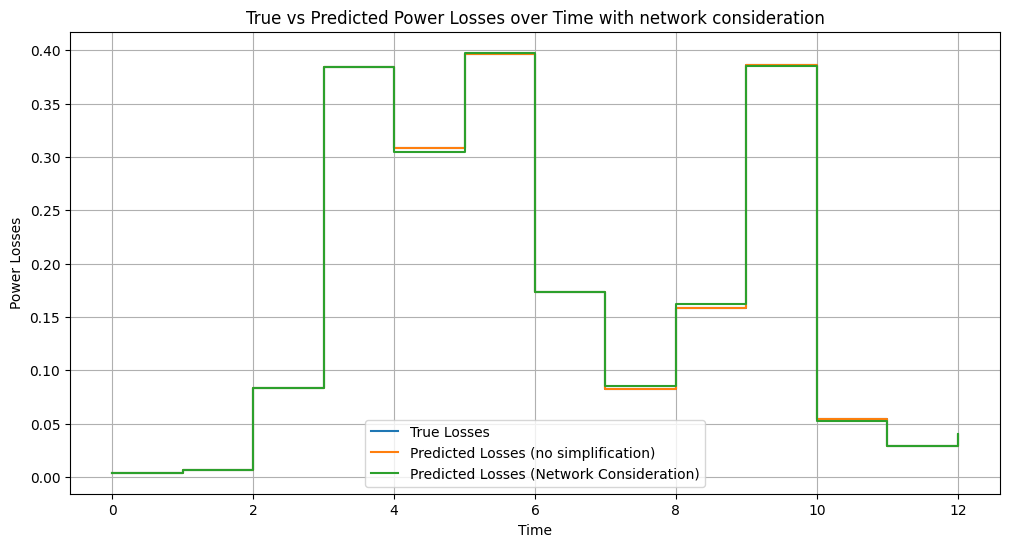

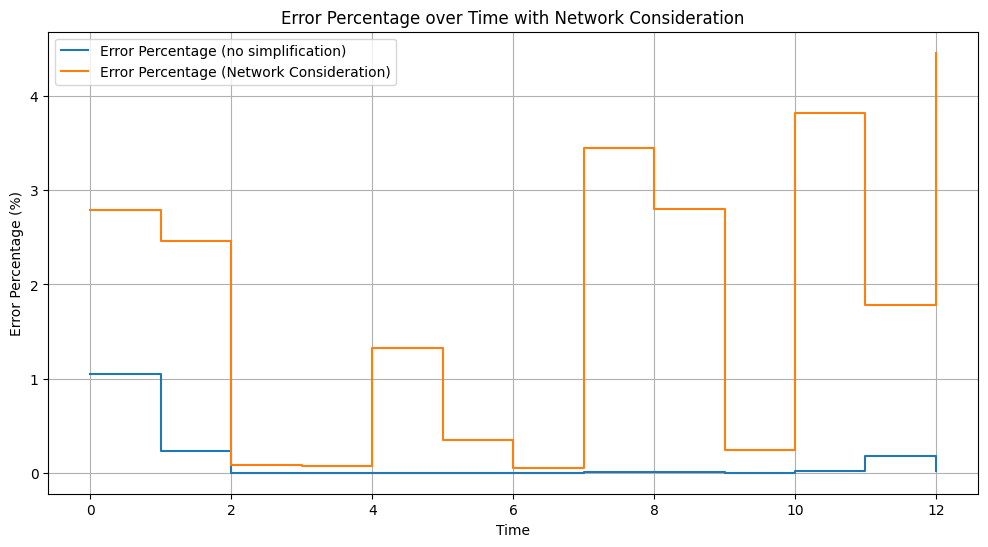

In [50]:
# 1) Matix X only considers 2.Pi.Pj when there is a connection between the buses i and j (i.e., when there is a line between them)
X_1 = np.zeros((T, q))
for m in range (time):
    k = 0
    for i in range(n):
        X_1[m, k] = P[m, i]**2
        k += 1
    for i in range(n):
        for j in range(i + 1, n):
            if Y[i, j] != 0:  # Only consider the product if there is a line between bus i and j
                X_1[m, k] = 2 * P[m, i] * P[m, j]
            else:
                X_1[m, k] = 0  # Set to zero if there is no line
            k += 1

beta_1 = np.linalg.lstsq(X_1, PL2, rcond=None)[0]
PL_predicted_1 = X_1.dot(beta_1)

# Plot difference in predicted losses using this new X matrix vs older prediction and real losses
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2, label='True Losses', where='post')
plt.step(range(time), PL_predicted, label='Predicted Losses (no simplification)', where='post')
plt.step(range(time), PL_predicted_1, label='Predicted Losses (Network Consideration)', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time with network consideration')
plt.legend()
plt.grid(True)
plt.show()

error_percent_1 = abs((PL_predicted_1 - PL2) / PL2 * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent, label='Error Percentage (no simplification)', where='post')
plt.step(range(time), error_percent_1, label='Error Percentage (Network Consideration)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage over Time with Network Consideration')
plt.legend()
plt.grid(True)
plt.show()

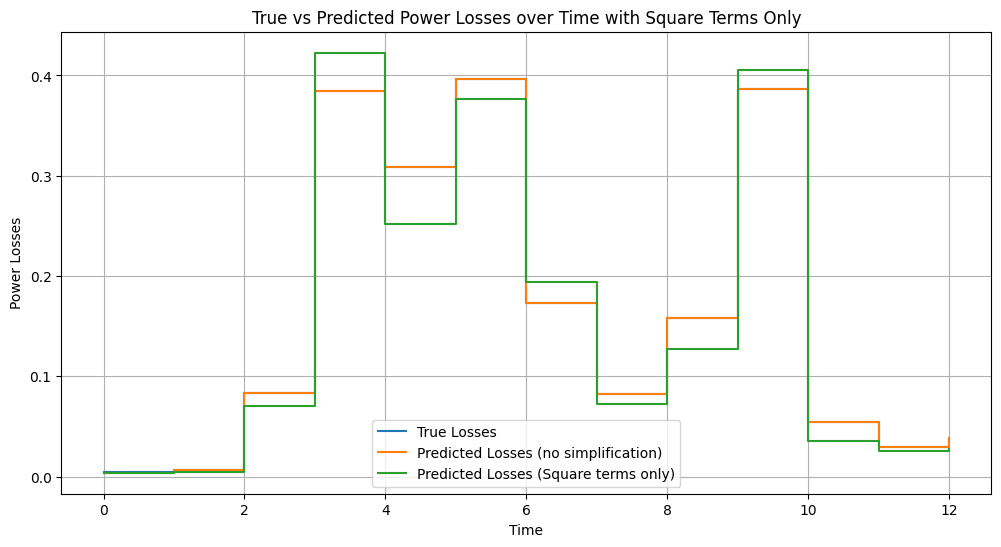

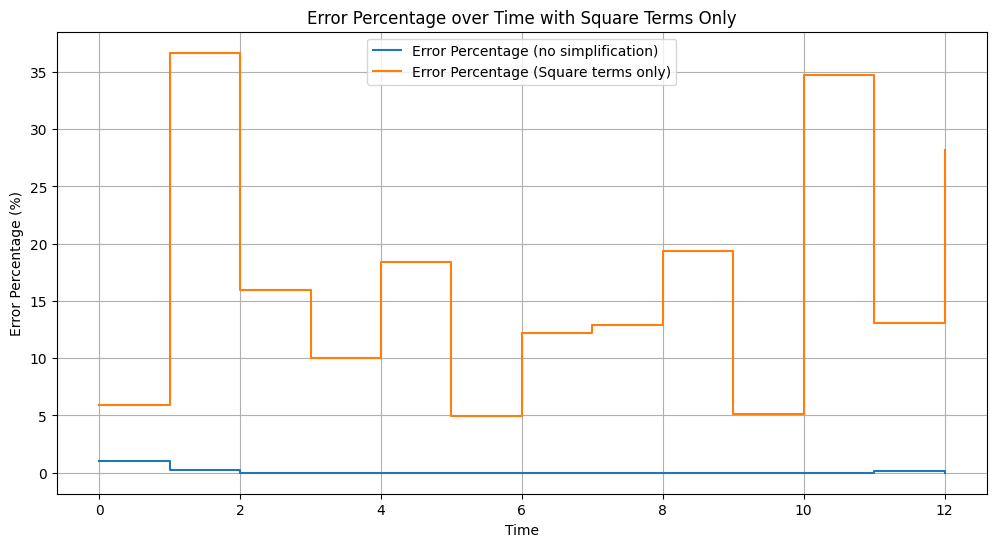

In [51]:
# 2) Reducing the dimensionality of X by only considering square terms
X_2 = np.zeros((T, 4))
for m in range (time):
    for i in range(n):
        X_2[m, i] = P[m, i]**2

beta_2 = np.linalg.lstsq(X_2, PL2, rcond=None)[0]
PL_predicted_2 = X_2.dot(beta_2)

# Plot difference in predicted losses using this new X matrix vs older prediction and real losses
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2, label='True Losses', where='post')
plt.step(range(time), PL_predicted, label='Predicted Losses (no simplification)', where='post')
plt.step(range(time), PL_predicted_2, label='Predicted Losses (Square terms only)', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time with Square Terms Only')
plt.legend()
plt.grid(True)
plt.show()

error_percent_2 = abs((PL_predicted_2 - PL2) / PL2 * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent, label='Error Percentage (no simplification)', where='post')
plt.step(range(time), error_percent_2, label='Error Percentage (Square terms only)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage over Time with Square Terms Only')
plt.legend()
plt.grid(True)
plt.show()

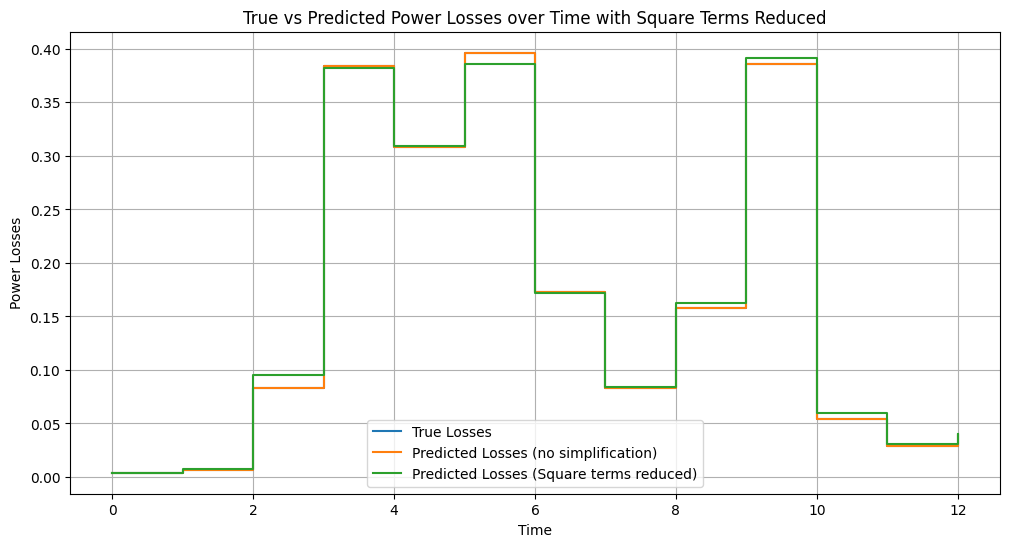

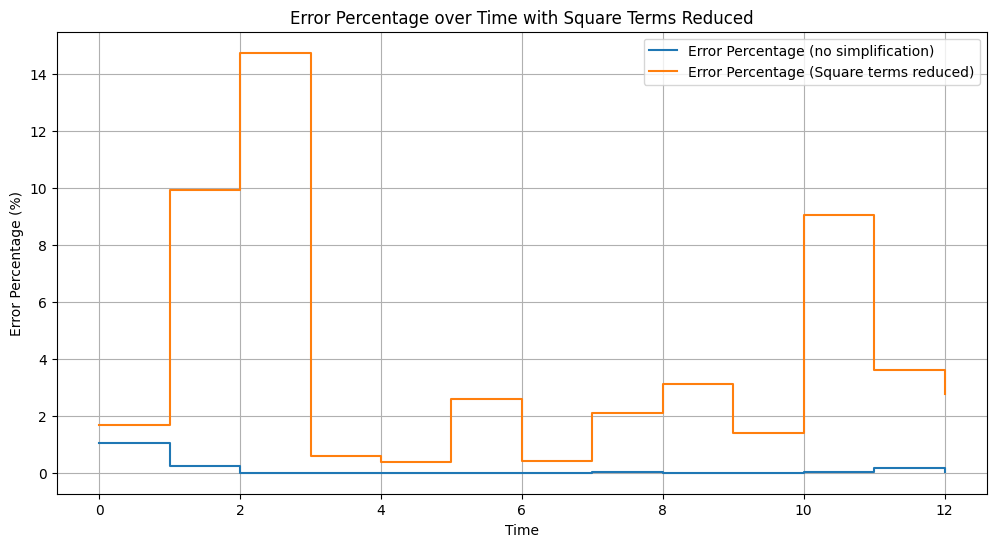

In [52]:
# 3) Reducing the dimensionality of X by summing electrically-close bus injections 
X_3 = np.zeros((T, 3))
for m in range (time):
    Psum = P[m, 0] + P[m, 1] + P[m, 2]  # Assuming buses 0, 1, and 2 are electrically close
    X_3[m, 0] = Psum**2
    X_3[m, 1] = 2*Psum*P[m, 3]
    X_3[m, 2] = P[m, 3]**2

beta_3 = np.linalg.lstsq(X_3, PL2, rcond=None)[0]
PL_predicted_3 = X_3.dot(beta_3)

# Plot difference in predicted losses using this new X matrix vs older prediction and real losses
plt.figure(figsize=(12, 6))
plt.step(range(time), PL2, label='True Losses', where='post')
plt.step(range(time), PL_predicted, label='Predicted Losses (no simplification)', where='post')
plt.step(range(time), PL_predicted_3, label='Predicted Losses (Square terms reduced)', where='post')
plt.xlabel('Time')
plt.ylabel('Power Losses')
plt.title('True vs Predicted Power Losses over Time with Square Terms Reduced')
plt.legend()
plt.grid(True)
plt.show()

error_percent_3 = abs((PL_predicted_3 - PL2) / PL2 * 100)
plt.figure(figsize=(12, 6))
plt.step(range(time), error_percent, label='Error Percentage (no simplification)', where='post')
plt.step(range(time), error_percent_3, label='Error Percentage (Square terms reduced)', where='post')
plt.xlabel('Time')
plt.ylabel('Error Percentage (%)')
plt.title('Error Percentage over Time with Square Terms Reduced')
plt.legend()
plt.grid(True)
plt.show()

# Comparison between 3 different approximations

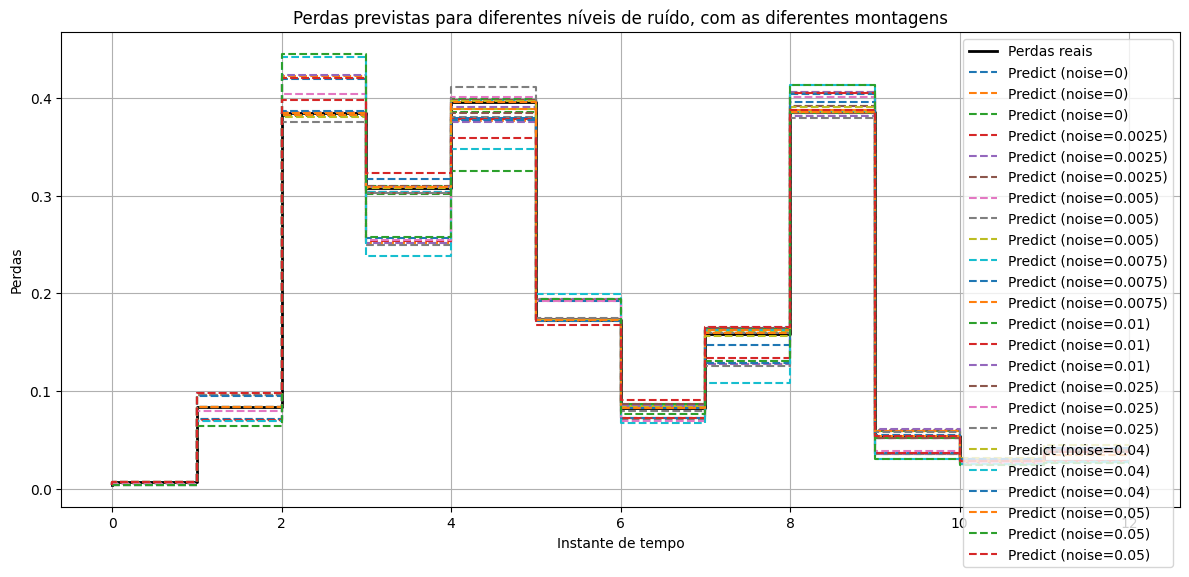

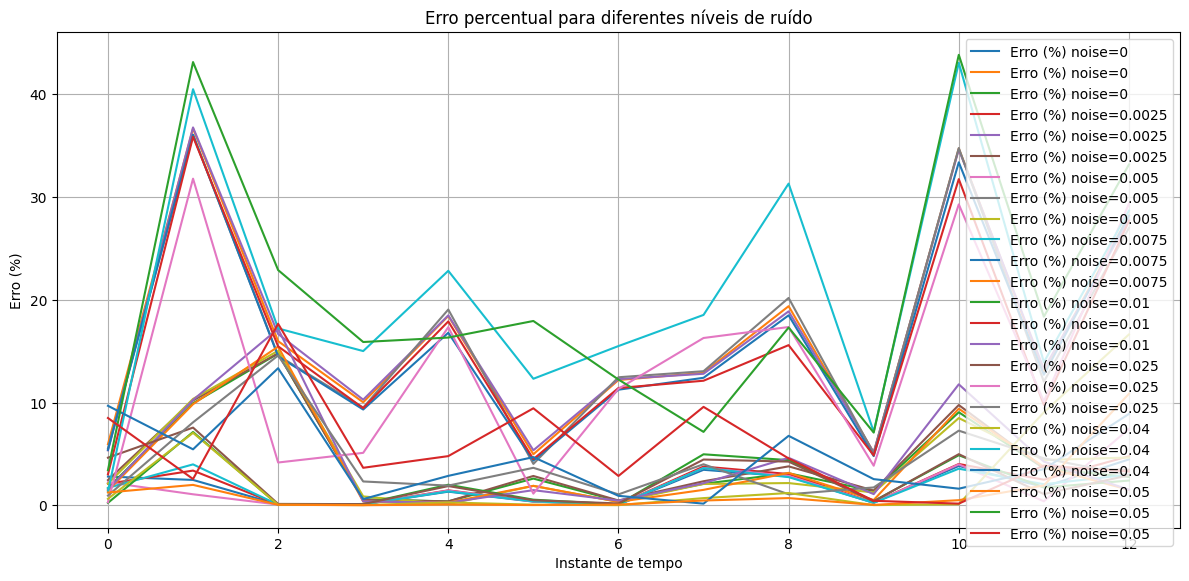

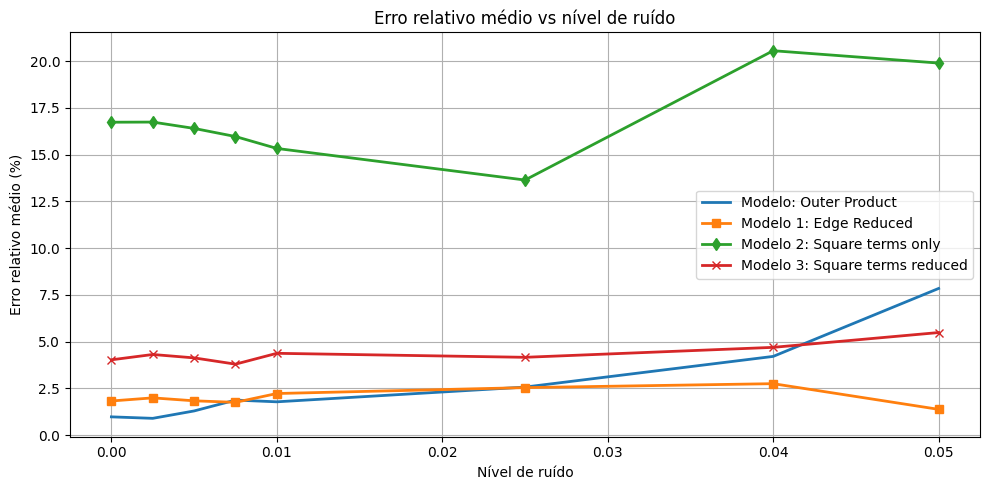

In [ ]:
predictions_by_noise_1 = {}
errors_by_noise_1 = {}
predictions_by_noise_2 = {}
errors_by_noise_2 = {}
predictions_by_noise_3 = {}
errors_by_noise_3 = {}

plt.figure(figsize=(12, 6))

plt.step(range(time), PL2, label='Perdas reais ', linewidth=2, color='black')

for noise in noise_levels:
    noise_X = noise * np.random.randn(*P.shape)
    P_noise_X = P * (1 + noise_X)

    # Adicionar ruído a X_1 X_2 e X_3
    X_1_noisy = np.zeros((T, q))
    X_2_noisy = np.zeros((T, 4))
    X_3_noisy = np.zeros((T, 3))
    for m in range (time):
        k = 0
        for i in range(n):
            X_1_noisy[m, k] = P_noise_X[m, i]**2
            X_2_noisy[m, i] = P_noise_X[m, i]**2
            k += 1
        for i in range(n):
            for j in range(i + 1, n):
                if Y[i, j] != 0:
                    X_1_noisy[m, k] = 2 * P_noise_X[m, i] * P_noise_X[m, j]
                else:
                    X_1_noisy[m, k] = 0
                k += 1

        Psum_noisy = P_noise_X[m, 0] + P_noise_X[m, 1] + P_noise_X[m, 2]
        X_3_noisy[m, 0] = Psum_noisy**2
        X_3_noisy[m, 1] = 2*Psum_noisy*P_noise_X[m, 3]
        X_3_noisy[m, 2] = P_noise_X[m, 3]**2

    beta_1_noisy = np.linalg.lstsq(X_1_noisy, PL2, rcond=None)[0]
    beta_2_noisy = np.linalg.lstsq(X_2_noisy, PL2, rcond=None)[0]
    beta_3_noisy = np.linalg.lstsq(X_3_noisy, PL2, rcond=None)[0]

    # keep track of the predicted losses for each noise level
    PL_pred_1_noisy = X_1_noisy.dot(beta_1_noisy)
    PL_pred_2_noisy = X_2_noisy.dot(beta_2_noisy)
    PL_pred_3_noisy = X_3_noisy.dot(beta_3_noisy)

    predictions_by_noise_1[noise] = PL_pred_1_noisy
    predictions_by_noise_2[noise] = PL_pred_2_noisy
    predictions_by_noise_3[noise] = PL_pred_3_noisy

    plt.step(range(time),PL_pred_1_noisy, '--', linewidth=1.5, label=f'Predict Edge Reduced (noise={noise})')
    plt.step(range(time),PL_pred_2_noisy, '--', linewidth=1.5, label=f'Predict Square terms only (noise={noise})')
    plt.step(range(time),PL_pred_3_noisy, '--', linewidth=1.5, label=f'Predict Square terms reduced (noise={noise})')

plt.xlabel("Instante de tempo")
plt.ylabel("Perdas")
plt.title("Perdas previstas para diferentes níveis de ruído, com as diferentes montagens")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for noise in noise_levels:
    PL_pred_1_noisy = predictions_by_noise_1[noise]
    PL_pred_2_noisy = predictions_by_noise_2[noise]
    PL_pred_3_noisy = predictions_by_noise_3[noise]
    error_percent_noise1 = np.abs((PL_pred_1_noisy - PL2) / PL2) * 100
    error_percent_noise2 = np.abs((PL_pred_2_noisy - PL2) / PL2) * 100
    error_percent_noise3 = np.abs((PL_pred_3_noisy - PL2) / PL2) * 100
    errors_by_noise_1[noise] = error_percent_noise1
    errors_by_noise_2[noise] = error_percent_noise2
    errors_by_noise_3[noise] = error_percent_noise3
    plt.plot(error_percent_noise1, label=f"Erro Edge Reduced(%) noise={noise}")
    plt.plot(error_percent_noise2, label=f"Erro Square terms only(%) noise={noise}")
    plt.plot(error_percent_noise3, label=f"Erro Square terms reduced(%) noise={noise}")

plt.xlabel("Instante de tempo")
plt.ylabel("Erro (%)")
plt.title("Erro percentual para diferentes níveis de ruído")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

mean_errors = [np.mean(errors_by_noise[n]) for n in noise_levels]
mean_errors_1 = [np.mean(errors_by_noise_1[n]) for n in noise_levels]
mean_errors_2 = [np.mean(errors_by_noise_2[n]) for n in noise_levels]
mean_errors_3 = [np.mean(errors_by_noise_3[n]) for n in noise_levels]

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, mean_errors, label='Modelo: Outer Product', linewidth=2)
plt.plot(noise_levels, mean_errors_1, label='Modelo 1: Edge Reduced', linewidth=2)
plt.plot(noise_levels, mean_errors_2, label='Modelo 2: Square terms only', linewidth=2)
plt.plot(noise_levels, mean_errors_3, label='Modelo 3: Square terms reduced', linewidth=2)
plt.xlabel("Nível de ruído")
plt.ylabel("Erro relativo médio (%)")
plt.title("Erro relativo médio vs nível de ruído")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Aqui podemos adicionar comparações e estudos deste género (ta nos slides)

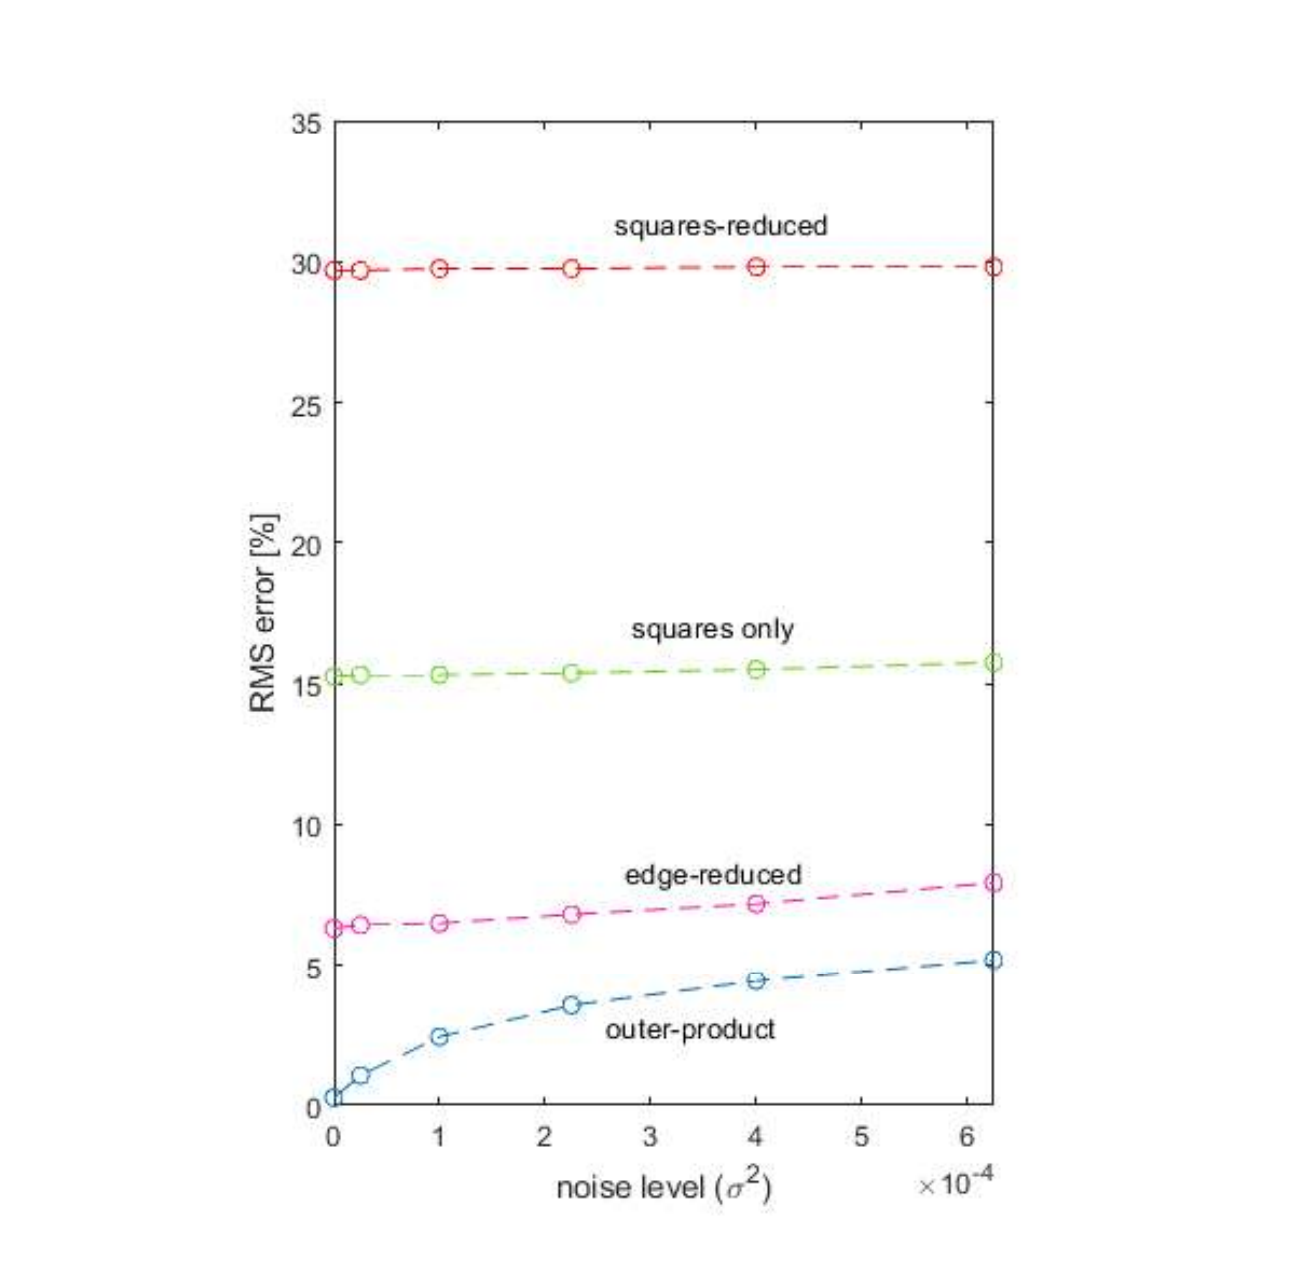

Só não fiz, porque não tinha a certeza de onde introduzir ruído, mas se perceberes onde, estás à vontade